In [21]:
import numpy as np
import pandas as pd

In [22]:
FILE_PATH = "./data/Churn_Modelling.csv"

In [23]:
df = pd.read_csv(FILE_PATH)
df.shape

(10000, 14)

In [24]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [28]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [29]:
df.groupby(['Geography', 'Exited']).size().reset_index(name = "Customer Count")

,Geography,Exited,Customer Count
0,France,0,4204
1,France,1,810
2,Germany,0,1695
3,Germany,1,814
4,Spain,0,2064
5,Spain,1,413


In [30]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [31]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1, inplace = True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
df = pd.get_dummies(df, columns = ['Geography', 'Gender'], drop_first = True, dtype = int)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [33]:
X = df.drop('Exited', axis = 1)
y = df['Exited']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]], shape=(8000, 11))

In [95]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

In [96]:
model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1],)))
model.add(Dense(8, activation = 'relu'))
model.add(Dense(4, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [97]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [98]:
model.compile(
    optimizer = 'adam', 
    loss = 'binary_crossentropy'
)

In [99]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 100,
    validation_split = 0.2
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5855 - val_loss: 0.5281
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4947 - val_loss: 0.4690
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4601 - val_loss: 0.4434
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4449 - val_loss: 0.4329
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4371 - val_loss: 0.4273
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4298 - val_loss: 0.4207
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4199 - val_loss: 0.4094
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4055 - val_loss: 0.3979
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3906 - val_loss: 0.3876
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3784 - val_loss: 0.3798
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3692 - val_loss: 0.3731
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━

In [100]:
import matplotlib.pyplot as plt


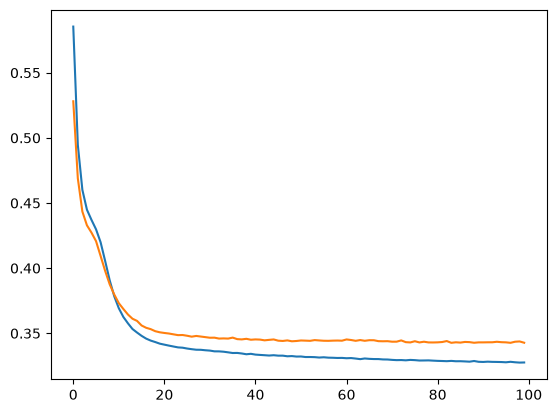

In [101]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')

In [102]:
model.layers[0].get_weights()

[array([[ 0.00564509, -0.1059932 ,  0.02105493,  0.03122115,  0.34203076,
         -0.15765725, -0.2915212 , -0.02274667],
        [-0.20681205,  1.5875497 ,  0.06257901, -0.2910027 , -0.27311435,
          0.99840254, -0.06171609, -0.11946877],
        [ 0.03080925, -0.29476672, -0.22575179, -0.37297267,  0.01286905,
         -0.0401089 , -0.16733529,  0.13267295],
        [ 0.43564948, -0.02132644,  0.2473467 ,  0.17332509, -0.81469816,
         -0.29709333, -0.26054013,  0.18907946],
        [ 1.1506453 ,  0.14132367,  1.5794553 , -0.19620974,  0.14261472,
         -0.69193107, -0.02416966,  0.29763088],
        [ 0.11071593,  0.14397106, -0.08663011,  0.25311765,  0.00481153,
         -0.09282367, -0.14694381, -0.25574964],
        [ 0.6202791 ,  0.7464878 , -0.18267764, -0.09851605,  0.42074013,
         -0.50915194, -0.14719243, -0.45930877],
        [ 0.14388208, -0.15444712, -0.236909  , -0.23578833, -0.18666932,
         -0.01396261,  0.10575356, -0.3117619 ],
        [-0.6172

In [103]:
model.layers[1].get_weights()

[array([[ 0.41710514, -0.5887492 ,  0.2776936 ,  0.36502898],
        [ 1.103457  , -0.6061659 , -1.1650231 , -0.04799723],
        [-0.5055198 , -0.8454931 , -0.44805875,  0.99861556],
        [-0.863878  ,  0.50149703,  0.6476357 , -0.58599055],
        [ 0.38724244,  0.60065746,  0.6204311 , -0.46264622],
        [-0.4824473 ,  0.79805285, -0.29255608,  0.04969303],
        [-0.3933587 ,  0.249753  ,  0.84821755,  0.1624926 ],
        [-0.05582992, -0.23260999,  0.44910094, -0.11929861]],
       dtype=float32),
 array([-0.04254666, -0.05732426,  0.7481207 , -0.29997146], dtype=float32)]

In [104]:
y_prediction = model.predict(X_test_scaled)
y_prediction

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([[0.03311309],
       [0.01465289],
       [0.11963282],
       ...,
       [0.6632325 ],
       [0.09299304],
       [0.27979025]], shape=(2000, 1), dtype=float32)

In [105]:
y_prediction = (y_prediction > 0.5).astype(int)

In [106]:
y_prediction

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(2000, 1))

In [107]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [108]:
accuracy_score(y_test, y_prediction)

0.8615

In [109]:
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.73      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [110]:
confusion_matrix(y_test, y_prediction)

array([[1537,   70],
       [ 207,  186]])